# GAN — generacion de insectos

Dataset: coleccion de insectos armada en conjunto con los compañeros de curso (no sintetico, no descargado de Kaggle) — cada quien aporto fotos reales de insectos, centralizadas y organizadas por Luis Fernando Quispe Sullca.

Arquitectura: DCGAN (Generador + Discriminador convolucionales), extraida de `01_gans.ipynb` — misma logica de entrenamiento (`fit()` identica), adaptada de imagenes 28x28 en blanco y negro (FashionMNIST) a imagenes 64x64 RGB (insectos).

In [5]:
import os, glob, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from fastprogress import master_bar, progress_bar

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Acceso al dataset
Corriendo local (no en Colab) no hace falta Google Drive — apuntamos directo a la carpeta en tu disco.

In [6]:
DATASET_PATH = r'C:\Erick\IA\Datasets\datasetfinal'  # ruta local directa, no hace falta Drive corriendo local

EXTENSIONES = ('.jpg', '.jpeg', '.png', '.bmp')
image_paths = []
for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.lower().endswith(EXTENSIONES):
            image_paths.append(os.path.join(root, f))

print('imagenes encontradas:', len(image_paths))

imagenes encontradas: 272136


### Dataset y normalizacion
Adaptacion respecto a `01_gans.ipynb`: ahi las imagenes ya venian cargadas en memoria (FashionMNIST via torchvision, 28x28, 1 canal). Acá las cargamos nosotros desde disco con PIL, las redimensionamos a 64x64 y las dejamos en 3 canales (RGB) — el resto de la normalizacion es igual: `imgs * 2 - 1` para llevarlas al rango [-1, 1], porque el generador termina en `Tanh` (salida entre -1 y 1).

In [7]:
IMG_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # deja los valores en [0, 1]
    transforms.Normalize([0.5]*3, [0.5]*3),  # -> [-1, 1], igual que "imgs * 2. - 1." del cuadernillo
])

class InsectosDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, ix):
        img = Image.open(self.paths[ix]).convert('RGB')
        return self.transform(img)

train = InsectosDataset(image_paths, transform)
dataloader = DataLoader(train, batch_size=16, shuffle=True)  # 16 en vez de 32: tu GPU tiene solo 2GB de VRAM
imgs = next(iter(dataloader))
imgs.shape

torch.Size([16, 3, 64, 64])

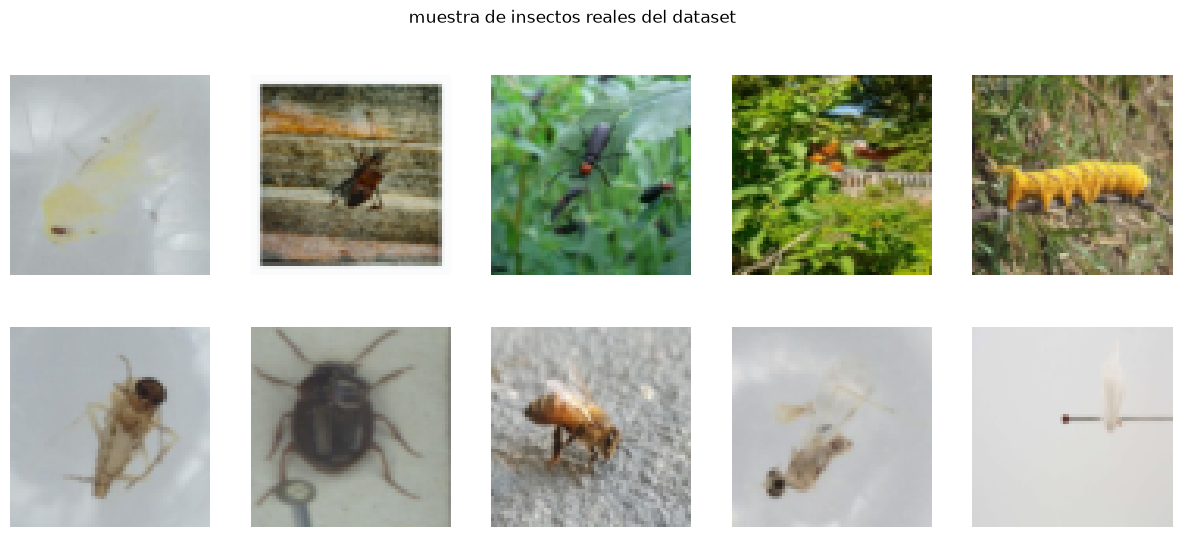

In [8]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axs.flat):
    img = (imgs[i].permute(1,2,0).numpy() * 0.5) + 0.5  # desnormalizar para mostrar
    ax.imshow(img.clip(0,1))
    ax.axis('off')
plt.suptitle('muestra de insectos reales del dataset')
plt.show()

### Generador (DCGAN)
Mismo patron que `01_gans.ipynb` (`Linear` -> reshape -> `ConvTranspose2d` con `BatchNorm`+`ReLU`, `Tanh` a la salida). La diferencia: el cuadernillo original va de 7x7 a 28x28 en 2 pasos (28 = 7*2*2) y termina en 1 canal; acá necesitamos llegar a 64x64 en 3 canales, asi que partimos de 4x4 y agregamos 2 capas mas de `ConvTranspose2d` (4 pasos: 4->8->16->32->64).

In [9]:
class Generator(nn.Module):
    def __init__(self, input_size=100):
        super().__init__()
        self.input_size = input_size
        self.inp = nn.Sequential(
            nn.Linear(input_size, 4*4*256),
            nn.BatchNorm1d(4*4*256),
        )
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),  # 4 -> 8
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),   # 8 -> 16
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),    # 16 -> 32
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1, bias=False),     # 32 -> 64, 3 canales RGB
            nn.Tanh()
        )

    def forward(self, x):
        x = self.inp(x)
        x = x.view(-1, 256, 4, 4)
        x = self.main(x)
        return x

generator = Generator()
out = generator(torch.randn(8, 100))
out.shape

torch.Size([8, 3, 64, 64])

### Discriminador (DCGAN)
Simetrico al generador — mismo patron del cuadernillo (`Conv2d` + `BatchNorm` + `ReLU`, `Linear` + `Sigmoid` a la salida), extendido con 2 capas mas para bajar de 64x64 hasta 4x4 antes del `Linear` final.

In [10]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1, bias=False),    # 64 -> 32
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1, bias=False),   # 32 -> 16
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),  # 16 -> 8
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False), # 8 -> 4
            nn.BatchNorm2d(256), nn.ReLU(True),
        )
        self.out = nn.Sequential(
            nn.Linear(256*4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # a diferencia del cuadernillo (que recibia vectores planos de 28*28 y los reshapeaba),
        # aca ya recibimos imagenes con su forma (batch, 3, 64, 64) directamente
        x = self.main(x)
        x = x.view(x.size(0), -1)
        return self.out(x)

discriminator = Discriminator()
out = discriminator(torch.randn(8, 3, 64, 64))
out.shape

torch.Size([8, 1])

### Entrenamiento
La funcion `fit()` es identica a la de `01_gans.ipynb` — se entrena primero el discriminador (distinguir reales vs generadas) y despues el generador (enganiar al discriminador), en cada batch. Unico cambio: `X` ya viene con forma de imagen `(B, 3, 64, 64)` en vez de vector plano, asi que no hace falta el `.view(X.size(0), -1)` que tenia el original para el caso MLP.

In [11]:
def fit(g, d, dataloader, epochs=50, crit=None):
    g.to(device)
    d.to(device)
    g_optimizer = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5, 0.999))
    crit = nn.BCELoss() if crit is None else crit
    hist = {'g_loss': [], 'd_loss': []}
    mb = master_bar(range(1, epochs+1))
    for epoch in mb:
        g_loss_ep, d_loss_ep = [], []
        for X in progress_bar(dataloader, parent=mb):
            X = X.to(device)
            # --- entrenamos el discriminador ---
            g.eval(); d.train()
            noise = torch.randn(X.size(0), g.input_size).to(device)
            generated = g(noise)
            d_input = torch.cat([generated, X])
            d_gt = torch.cat([torch.zeros(X.size(0)), torch.ones(X.size(0))]).view(-1,1).to(device)
            d_optimizer.zero_grad()
            d_l = crit(d(d_input), d_gt)
            d_l.backward()
            d_optimizer.step()
            d_loss_ep.append(d_l.item())
            # --- entrenamos el generador ---
            g.train(); d.eval()
            noise = torch.randn(X.size(0), g.input_size).to(device)
            generated = g(noise)
            g_gt = torch.ones(X.size(0)).view(-1,1).to(device)
            g_optimizer.zero_grad()
            g_l = crit(d(generated), g_gt)
            g_l.backward()
            g_optimizer.step()
            g_loss_ep.append(g_l.item())
            mb.child.comment = f'g_loss {np.mean(g_loss_ep):.4f} d_loss {np.mean(d_loss_ep):.4f}'
        hist['g_loss'].append(np.mean(g_loss_ep))
        hist['d_loss'].append(np.mean(d_loss_ep))
        mb.write(f'Epoch {epoch}/{epochs} g_loss {hist["g_loss"][-1]:.4f} d_loss {hist["d_loss"][-1]:.4f}')
    return hist

hist = fit(generator, discriminator, dataloader, epochs=50)

<div><div><progress max="50" value="12"></progress> 24.00% [12/50 7:03:32&lt;22:21:12]</div><div><p>Epoch 1/50 g_loss 0.8138 d_loss 0.0154</p><p>Epoch 2/50 g_loss 0.7690 d_loss 0.0126</p><p>Epoch 3/50 g_loss 1.2924 d_loss 0.0056</p><p>Epoch 4/50 g_loss 39.1937 d_loss 0.0004</p><p>Epoch 5/50 g_loss 26.6441 d_loss 0.0026</p><p>Epoch 6/50 g_loss 27.5788 d_loss 0.0019</p><p>Epoch 7/50 g_loss 32.2088 d_loss 0.0017</p><p>Epoch 8/50 g_loss 26.1477 d_loss 0.0023</p><p>Epoch 9/50 g_loss 31.8783 d_loss 0.0010</p><p>Epoch 10/50 g_loss 31.6619 d_loss 0.0017</p><p>Epoch 11/50 g_loss 46.0607 d_loss 0.0001</p><p>Epoch 12/50 g_loss 22.0464 d_loss 0.0014</p></div><div><progress max="17009" value="74"></progress> 0.44% [74/17009 00:07&lt;29:08... g_loss 40.1807 d_loss 0.0000]</div></div>

KeyboardInterrupt: 

In [12]:
import pandas as pd
pd.DataFrame(hist).plot(grid=True, figsize=(8,4), title='perdida del generador y discriminador')
plt.show()

NameError: name 'hist' is not defined

### Insectos generados
Mismo bloque final que `01_gans.ipynb`: tomamos ruido aleatorio, lo pasamos por el generador ya entrenado, y mostramos el resultado.

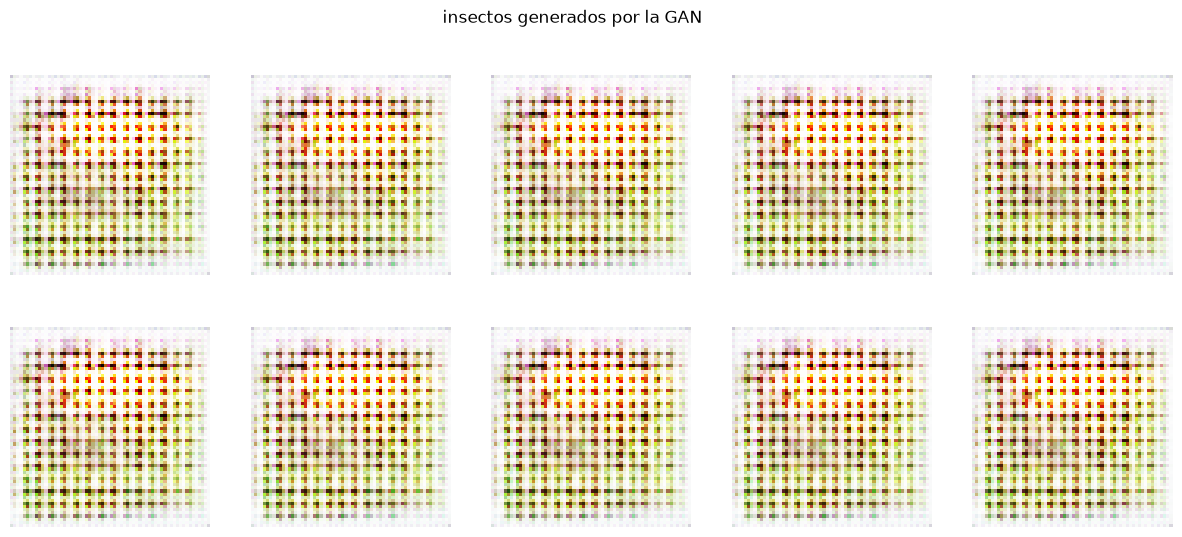

In [13]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(10, generator.input_size).to(device)
    generated = generator(noise).cpu()

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axs.flat):
    img = (generated[i].permute(1,2,0).numpy() * 0.5) + 0.5
    ax.imshow(img.clip(0,1))
    ax.axis('off')
plt.suptitle('insectos generados por la GAN')
plt.show()

**Nota para la defensa**: las GANs son notoriamente inestables y lentas de entrenar bien — no te preocupes si a las 50 épocas los insectos generados se ven borrosos o poco definidos, es normal en las primeras corridas. Si querés mejorar la calidad: más épocas (100-200), más imágenes en el dataset, o achicar el learning rate si ves que el `d_loss` se va a 0 muy rápido (señal de que el discriminador está ganando demasiado fácil, y el generador deja de aprender — esto se llama *mode collapse* o desbalance generador/discriminador).